# Uniaxial Concrete

In [1]:
from numpy import sin, linspace, pi
import numpy as np
import matplotlib.pyplot as plt

For convenience, import unit constants from the {ref}`units` submodule and define parameters.

In [2]:
from xara.units.english import ksi, psi
from math import sqrt

# nominal concrete compressive strength
fc = -8.5*ksi              # Concrete compressive strength ksi   (+Tension -Compression)
Ec = 57*ksi*sqrt(-fc/psi)  # Concrete Elastic Modulus

# unconfined concrete
ec0 = -0.003             # strain at maximum strength of unconfined concrete
fc2U = 0.2*fc            # ultimate stress
ecu = -0.01              # strain at ultimate stress
_lambda = 0.1            # ratio between unloading slope at ecu and initial slope Ec

# tensile-strength properties
ftU = abs(0.14*fc)         # tensile strength (positive)
Ets = ftU/0.002            # tension softening stiffness

Next create a {ref}`Concrete01` material.

In [3]:
import xara 
# (Todeschini parabola) 
concrete01 = xara.UniaxialMaterial("Concrete01", 
    Fc=fc, 
    nu=0.2, 
    ec0=ec0, 
    Fcu=fc2U, 
    ecu=ecu, 
)


strain = -0.005*sin(linspace(0, 2.0*pi, 100))

stress = []
with concrete01 as tmp:

    for e in strain:
        stress.append(tmp.getStress(e, commit=True)/fc)


Now that the stress and strain are stored, they can be plotted using `matplotlib`

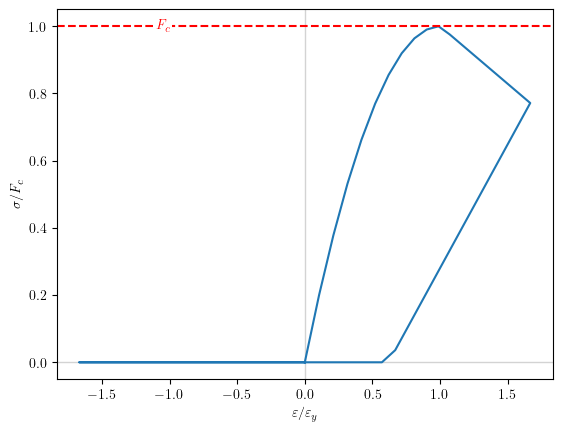

In [4]:

# create a plotting figure
fig, ax = plt.subplots()
ax.axhline(0, color='lightgrey', linestyle='-', linewidth=1)
ax.axvline(0, color='lightgrey', linestyle='-', linewidth=1)
ln = ax.plot(strain/ec0, stress)

# mark_slope(ax, ln[0], 0.25, 0.75, iend=20, label="$E$", color='k', ls='--')
ax.axhline(y=1, color='r', linestyle='--')
ax.text(-1, 1, r"$F_c$", color='r', va='center', ha='right', bbox=dict(facecolor='white', edgecolor='none', pad=2.0))

ax.set_xlabel(r"$\varepsilon/\varepsilon_y$")
ax.set_ylabel(r"$\sigma/F_c$");


In [ ]:
ConcreteMaterials = [
    xara.UniaxialMaterial(
        type="Concrete01",
        nu=0.2,
        Fc=fc,
        ec0=ec0,
        Fcu=fc2U,
        ecu=ecu,#-1,#
        # Ec = Ec,
    ),
    xara.UniaxialMaterial(
        type="Concrete02",
        nu=0.2,
        Fc=fc,
        ec0=ec0,
        Fcu=fc2U,
        ecu=ecu,
        ft=ftU,
        Ets=Ets,
        # Ec = Ec,
    ),
    xara.UniaxialMaterial(
        type="Concrete04",
        Fc=fc,
        nu=0.2,
        ec0=ec0,
        # Fcu=fc2U,
        ecu=ecu,#-1,#
        Ec = Ec,
    ),
    xara.UniaxialMaterial("ASDConcrete1D",
        Ec,
        fc=fc,
        ft=ftU
    ),
    xara.UniaxialMaterial("Continuum", 
        xara.MultiaxialMaterial("FariaPlasticDamage",
            E=Ec, 
            nu = 0.2,
            Fc = fc,
            scale_peak=True,
            Ft = ftU,
            beta=0.0,
            Ap=2.5, An=3, Bn=0.75
        ),
    )
]


## Compression Envelope

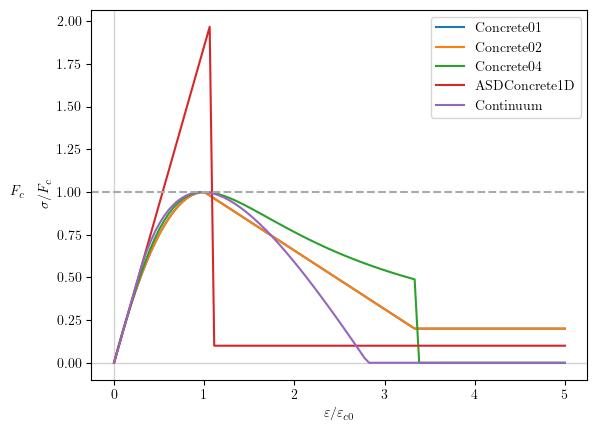

In [6]:
fig, ax = plt.subplots()
ax.axhline(0, color='lightgrey', linestyle='-', linewidth=1)
ax.axvline(0, color='lightgrey', linestyle='-', linewidth=1)

strain = np.linspace(0, 5*ec0, 100)


for material in ConcreteMaterials:
    with material as tmp:
        ln = ax.plot(strain/ec0, 
                    [tmp.getStress(e, commit=True)/fc for e in strain], label=material.type)


# Draw a horizontal line at the yield stress Fy
ax.axhline(y=1, color='darkgrey', linestyle='--')
ax.text(-1, 1, r"$F_c$", color='k', va='center', ha='right', bbox=dict(facecolor='white', edgecolor='none', pad=2.0))

ax.set_xlabel(r"$\varepsilon/\varepsilon_{c0}$")
ax.set_ylabel(r"$\sigma/F_c$");
ax.legend();

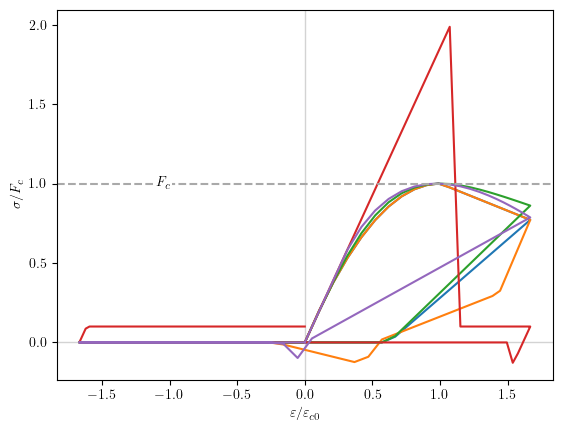

In [7]:
fig, ax = plt.subplots()
ax.axhline(0, color='lightgrey', linestyle='-', linewidth=1)
ax.axvline(0, color='lightgrey', linestyle='-', linewidth=1)

strain = -0.005*sin(linspace(0, 2.0*pi, 100))


for material in ConcreteMaterials:
    with material as tmp:
        ln = ax.plot(strain/ec0, 
                    [tmp.getStress(e, commit=True)/fc for e in strain])

# Draw a horizontal line at the yield stress Fy
ax.axhline(y=1, color='darkgrey', linestyle='--')
ax.text(-1, 1, r"$F_c$", color='k', va='center', ha='right', bbox=dict(facecolor='white', edgecolor='none', pad=2.0))

ax.set_xlabel(r"$\varepsilon/\varepsilon_{c0}$")
ax.set_ylabel(r"$\sigma/F_c$");